In [20]:
import pandas as pd

In [21]:
train_df = pd.read_csv("/Users/apple/Documents/Projects/Nasa RUL MLE/data/processed/feature_engineered_train.csv")
test_df = pd.read_csv("/Users/apple/Documents/Projects/Nasa RUL MLE/data/processed/feature_engineered_test.csv")
rul_df = pd.read_csv("/Users/apple/Documents/Projects/Nasa RUL MLE/data/processed/rul_clean.csv")

In [22]:
# Features & target
X = train_df.drop(columns=["engine_id", "rul"])
y = train_df["rul"]

test_last = test_df.groupby("engine_id").last().reset_index()
X_test = test_last.drop(columns=["engine_id"])
y_test = rul_df["rul"]

In [23]:
print("X shape:", X.shape)
print("X_test shape:", X_test.shape)

X shape: (20631, 43)
X_test shape: (100, 43)


In [24]:
# Train / Evaluation split
from sklearn.model_selection import train_test_split

X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

In [25]:
# Evaluation metrics function
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np

def evaluate(model, X_val, y_val):
    preds = model.predict(X_val)
    
    rmse = np.sqrt(mean_squared_error(y_val, preds))
    mae = mean_absolute_error(y_val, preds)
    r2 = r2_score(y_val, preds)
    
    return rmse, mae, r2

In [26]:
# Linear regression
from sklearn.linear_model import LinearRegression

lr = LinearRegression()
lr.fit(X_train, y_train)

rmse_train_lr, mae_train_lr, r2_train_lr = evaluate(lr, X_val, y_val)
rmse_test_lr, mae_test_lr, r2_test_lr = evaluate(lr, X_test, y_test)

In [27]:
# Random forest
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(
    n_estimators=100,
    max_depth=10,
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train, y_train)

rmse_train_rf, mae_train_rf, r2_train_rf = evaluate(rf, X_val, y_val)
rmse_test_rf, mae_test_rf, r2_test_rf = evaluate(rf, X_test, y_test)

In [28]:
import pandas as pd

importance = pd.Series(rf.feature_importances_, index=X.columns)
importance.sort_values(ascending=False).head(10)

sensor_4_rolling_mean     0.632494
cycle                     0.135050
sensor_11_rolling_mean    0.092636
sensor_9_rolling_mean     0.036098
sensor_15_rolling_mean    0.027818
sensor_14_rolling_mean    0.011594
sensor_7_rolling_mean     0.008066
sensor_12_rolling_mean    0.007027
sensor_2_rolling_mean     0.005780
sensor_9                  0.004704
dtype: float64

In [29]:
# XGBoost
from xgboost import XGBRegressor

xgb = XGBRegressor(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

xgb.fit(X_train, y_train)

rmse_train_xgb, mae_train_xgb, r2_train_xgb = evaluate(xgb, X_val, y_val)
rmse_test_xgb, mae_test_xgb, r2_test_xgb = evaluate(xgb, X_test, y_test)

In [30]:
# Ridge regression
from sklearn.linear_model import Ridge

ridge = Ridge(alpha=1.0)
ridge.fit(X_train, y_train)

rmse_train_ridge, mae_train_ridge, r2_train_ridge = evaluate(ridge, X_val, y_val)
rmse_test_ridge, mae_test_ridge, r2_test_ridge = evaluate(ridge, X_test, y_test)

In [31]:
results = pd.DataFrame({
    "Model": ["Linear", "Ridge", "Random Forest", "XGBoost"],
    "RMSE Train": [rmse_train_lr, rmse_train_ridge, rmse_train_rf, rmse_train_xgb],
    "RMSE Test": [rmse_test_lr, rmse_test_ridge, rmse_test_rf, rmse_test_xgb],
    "MAE Train": [mae_train_lr, mae_train_ridge, mae_train_rf, mae_train_xgb],
    "MAE Test": [mae_test_lr, mae_test_ridge, mae_test_rf, mae_test_xgb],
    "R2 Train": [r2_train_lr, r2_train_ridge, r2_train_rf, r2_train_xgb],
    "R2 Test": [r2_test_lr, r2_test_ridge, r2_test_rf, r2_test_xgb]
})

results.sort_values(by="RMSE Test")

,Model,RMSE Train,RMSE Test,MAE Train,MAE Test,R2 Train,R2 Test
2,Random Forest,14.030467,18.862957,9.230606,13.856097,0.883967,0.793956
3,XGBoost,14.019452,19.581125,9.372109,14.246944,0.884149,0.777968
0,Linear,19.760596,22.225835,16.011721,17.337570,0.769836,0.713940
1,Ridge,19.760354,22.226329,16.011517,17.337905,0.769842,0.713928


In [32]:
best_model1 = rf  # example

preds_test = best_model1.predict(X_test)

rmse_test = np.sqrt(mean_squared_error(y_test, preds_test))
mae_test = mean_absolute_error(y_test, preds_test)

print("Test RMSE:", rmse_test)
print("Test MAE:", mae_test)

Test RMSE: 18.862957215856177
Test MAE: 13.856096697700579


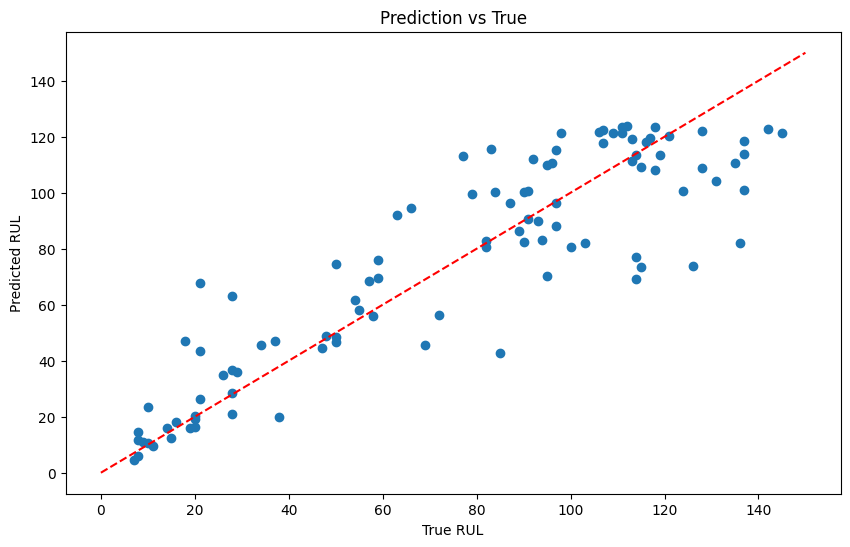

In [33]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))
plt.scatter(y_test, preds_test)
plt.xlabel("True RUL")
plt.ylabel("Predicted RUL")
plt.title("Prediction vs True")
plt.plot([0,150], [0,150], 'r--')
plt.show()

In [34]:
best_model2 = xgb  # example

preds_test = best_model2.predict(X_test)

rmse_test = np.sqrt(mean_squared_error(y_test, preds_test))
mae_test = mean_absolute_error(y_test, preds_test)

print("Test RMSE:", rmse_test)
print("Test MAE:", mae_test)

Test RMSE: 19.58112538112675
Test MAE: 14.246944427490234


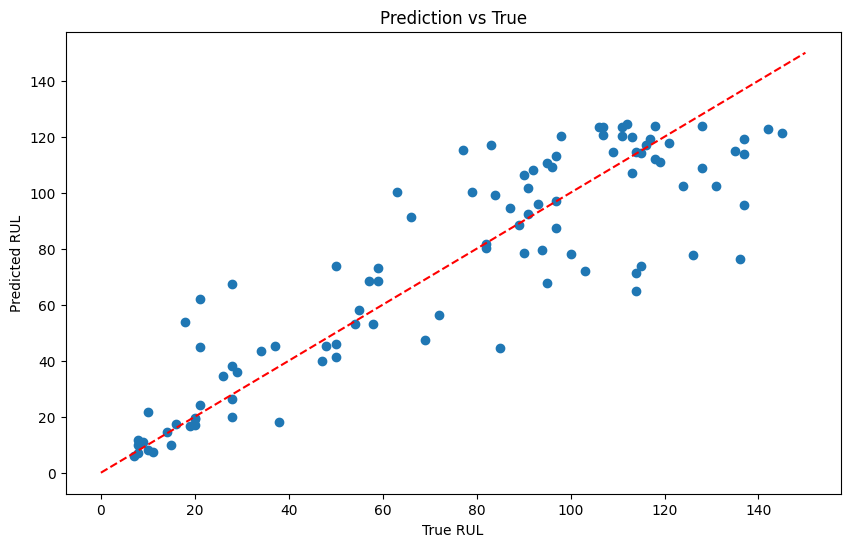

In [35]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))
plt.scatter(y_test, preds_test)
plt.xlabel("True RUL")
plt.ylabel("Predicted RUL")
plt.title("Prediction vs True")
plt.plot([0,150], [0,150], 'r--')
plt.show()

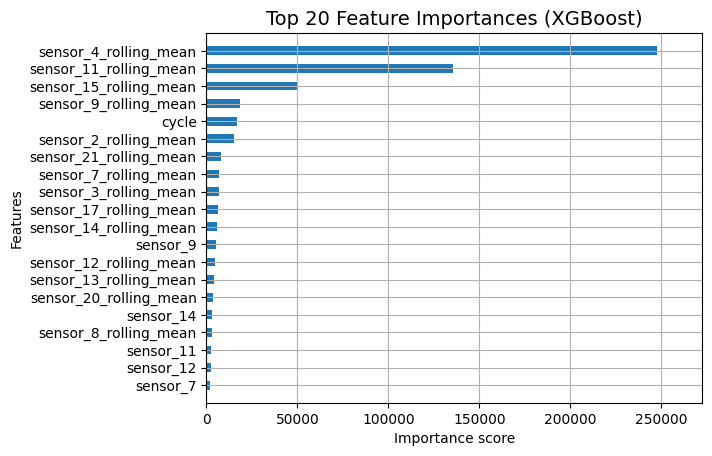

In [36]:
# Plot importances
import matplotlib.pyplot as plt
from xgboost import plot_importance

plot_importance(
    xgb,
    importance_type="gain",
    max_num_features=20,
    height=0.5,
    show_values=False
)
plt.title("Top 20 Feature Importances (XGBoost)", fontsize=14)
plt.show()